✅ Preview of Data Used:



,title,listed_in,description,type,release_year
0,Dick Johnson Is Dead,Documentaries,"As her father nears the end of his life, filmm...",Movie,2020
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",TV Show,2021
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,TV Show,2021
3,Jailbirds New Orleans,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",TV Show,2021
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,TV Show,2021



=== Top genres per GenreCluster ===
Cluster 0: Thrillers, Horror Movies, Docuseries, International Movies, Reality TV, Crime TV Shows, Science & Nature TV, Independent Movies
Cluster 1: Comedies, International Movies, Romantic Movies, Dramas, Music & Musicals, Independent Movies, Action & Adventure, Horror Movies
Cluster 2: International TV Shows, TV Dramas, Crime TV Shows, Romantic TV Shows, TV Comedies, Spanish-Language TV Shows, British TV Shows, Korean TV Shows
Cluster 3: Action & Adventure, International Movies, Dramas, Sci-Fi & Fantasy, Comedies, Anime Features, Classic Movies, Horror Movies
Cluster 4: Dramas, International Movies, Independent Movies, Romantic Movies, Thrillers, Music & Musicals, Sports Movies, Classic Movies
Cluster 5: Documentaries, International Movies, Music & Musicals, Sports Movies, LGBTQ Movies, Children & Family Movies, Classic Movies, Faith & Spirituality
Cluster 6: Children & Family Movies, Comedies, Dramas, Music & Musicals, Sci-Fi & Fantasy, Action &

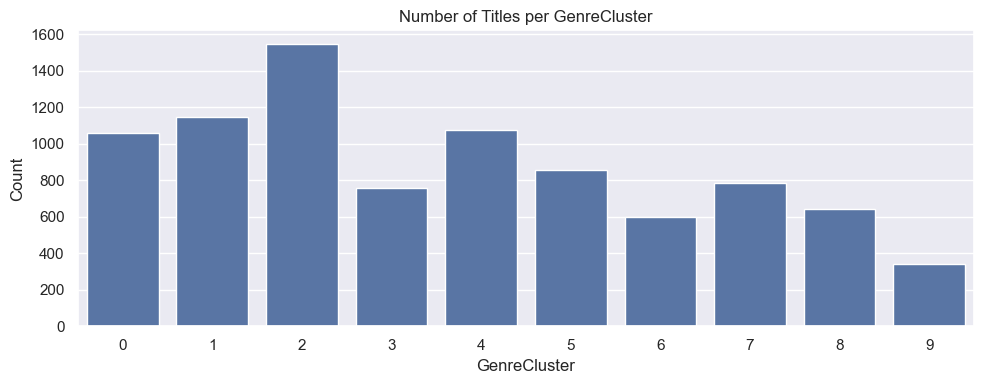


Enter a show/movie to get 5 recommendations.
Type 'quit' to exit.


🎬 You watched: 'Gone are the Days'
⚠️ Similarity search returned no close matches.

📌 Showing most recent titles instead:

1. Blood & Water | International TV Shows, TV Dramas, TV Mysteries
   After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth....

2. Ganglands | Crime TV Shows, International TV Shows, TV Action & Adventure
   To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war....

3. Jailbirds New Orleans | Docuseries, Reality TV
   Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series....

4. Chicago Party Aunt | TV Comedies
   Chicago Party Aunt Diane is an idolized troublemaker with a talent for avoiding adulthood — and a soft spot for

In [3]:
# ==== Imports ====
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

import re
import difflib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import PCA
from IPython.display import display  # for neat table in Jupyter


# === Preview Netflix Dataset (Neat Table) ===
df_preview = pd.read_csv("Dataset/netflix_titles.csv")
print("✅ Preview of Data Used:\n")
display(df_preview[["title", "listed_in", "description", "type", "release_year"]].head())


# ==== Helpers ====
def clean_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_genre_tokens(s: str) -> str:
    parts = [p.strip().lower() for p in str(s).split(",") if p.strip()]
    return " ".join([p.replace("&", "and").replace(" ", "_") for p in parts])


# ==== Recommender ====
class NetflixRecommender:
    def __init__(self, data_path):
        self.netflix = pd.read_csv(data_path)

        # Fill NAs
        self.netflix["listed_in"]   = self.netflix["listed_in"].fillna("")
        self.netflix["description"] = self.netflix["description"].fillna("")

        # Clean text
        self.netflix["desc_clean"]  = self.netflix["description"].apply(clean_text)
        self.netflix["genre_clean"] = self.netflix["listed_in"].apply(normalize_genre_tokens)

        # Holders
        self.tfidf_desc = None
        self.X_desc     = None
        self.knn_model  = None

        self._mlb           = None
        self._genre_matrix  = None
        self.genre_classes_ = None
        self.pca_           = None

    # ---------- Prep ----------
    def preprocess(self):
        self.netflix["content_features"] = (
            self.netflix["desc_clean"] + " " + self.netflix["genre_clean"]
        )
        self.netflix["genres_list"] = self.netflix["listed_in"].apply(self._split_genres)

    @staticmethod
    def _split_genres(s):
        if not isinstance(s, str) or not s.strip():
            return []
        return [g.strip() for g in s.split(",") if g.strip()]

    # ---------- Clustering first (genres) ----------
    def cluster_genre(self, num_genre_clust=10, visualize=True, sample=3000, random_state=42):
        self._mlb = MultiLabelBinarizer()
        G = self._mlb.fit_transform(self.netflix["genres_list"])
        self._genre_matrix  = G
        self.genre_classes_ = self._mlb.classes_

        km = KMeans(n_clusters=num_genre_clust, n_init=10, random_state=random_state)
        self.netflix["GenreCluster"] = km.fit_predict(G)

        # Top genres per cluster
        print("\n=== Top genres per GenreCluster ===")
        for c in range(num_genre_clust):
            mask = (self.netflix["GenreCluster"] == c)
            if mask.sum() == 0:
                print(f"Cluster {c}: <empty>")
                continue
            cluster_mean = G[mask].mean(axis=0)
            top_idx = np.argsort(cluster_mean)[::-1][:8]
            top_gen = [self.genre_classes_[i] for i in top_idx]
            print(f"Cluster {c}: {', '.join(top_gen)}")

        # Countplot
        plt.figure(figsize=(10, 4))
        sns.countplot(x="GenreCluster", data=self.netflix)
        plt.title("Number of Titles per GenreCluster")
        plt.xlabel("GenreCluster"); plt.ylabel("Count")
        plt.tight_layout(); plt.show()


    # ---------- TF-IDF + KNN ----------
    def build_tfidf(self):
        self.tfidf_desc = TfidfVectorizer(
            stop_words="english",
            max_df=0.7,
            min_df=2,
            ngram_range=(1, 2),
            max_features=3000,
            sublinear_tf=True
        )
        self.X_desc = self.tfidf_desc.fit_transform(self.netflix["content_features"])

    def train_knn(self):
        self.knn_model = NearestNeighbors(
            n_neighbors=21, metric="cosine", algorithm="brute"
        )
        self.knn_model.fit(self.X_desc)

    # ---------- Utilities ----------
    @staticmethod
    def _jaccard_words(a_str: str, b_str: str) -> float:
        A = set(str(a_str).split())
        B = set(str(b_str).split())
        if not A and not B:
            return 0.0
        return len(A & B) / max(1, len(A | B))

    def get_popular_shows_df(self, top_k=5):
        """Return top-k most recent titles as a DataFrame with columns we print."""
        df = self.netflix.sort_values("release_year", ascending=False)
        return df.head(top_k)[["title", "listed_in", "description"]]

    # ---------- Recommend ----------
    def recommend(self, title, top_k=5, min_jaccard=0.30, enforce_same_type=True, year_window=None):
        """
        Cluster-first filtering + TF-IDF ranking.
        Fallback to 5 most recent titles if: title not found, no candidates, or no ranked results.
        """
        # --- title lookup ---
        idxs = self.netflix.index[self.netflix["title"].str.lower() == str(title).lower()]
        if len(idxs) == 0:
            print("❌ Title not found.")
            fallback = self.get_popular_shows_df(top_k=top_k)
            print("\n📌 Showing most recent titles instead:\n")
            for i, row in enumerate(fallback.itertuples(index=False), 1):
                print(f"{i}. {row.title} | {row.listed_in}")
                print(f"   {row.description[:150]}...\n")
            return []

        idx = idxs[0]
        watched = self.netflix.loc[idx]
        print(f"\n🎬 You watched: '{watched.title}'")

        # --- candidate mask within same cluster ---
        m = (self.netflix.index != idx)
        m &= (self.netflix["GenreCluster"] == watched.GenreCluster)
        if enforce_same_type:
            m &= (self.netflix["type"] == watched.type)

        jac = self.netflix["genre_clean"].apply(lambda g: self._jaccard_words(watched.genre_clean, g))
        m &= (jac >= min_jaccard)

        if (year_window is not None) and pd.notna(watched.release_year):
            lo, hi = watched.release_year - year_window, watched.release_year + year_window
            m &= self.netflix["release_year"].between(lo, hi, inclusive="both")

        cand_idx = self.netflix.index[m].tolist()

        # relax if empty
        if len(cand_idx) == 0:
            m2 = (self.netflix.index != idx) & (self.netflix["GenreCluster"] == watched.GenreCluster)
            if enforce_same_type:
                m2 &= (self.netflix["type"] == watched.type)
            jac2 = self.netflix["genre_clean"].apply(lambda g: self._jaccard_words(watched.genre_clean, g))
            m2 &= (jac2 >= 0.15)
            cand_idx = self.netflix.index[m2].tolist()

        # fallback if still empty
        if len(cand_idx) == 0:
            print("⚠️ No similar titles found in the same cluster.")
            fallback = self.get_popular_shows_df(top_k=top_k)
            print("\n📌 Showing most recent titles instead:\n")
            for i, row in enumerate(fallback.itertuples(index=False), 1):
                print(f"{i}. {row.title} | {row.listed_in}")
                print(f"   {row.description[:150]}...\n")
            return []

        # --- TF-IDF KNN ranking within candidates ---
        n_query = min(len(cand_idx), top_k + 30)
        distances, knn_indices = self.knn_model.kneighbors(self.X_desc[idx], n_neighbors=n_query)
        knn_indices = knn_indices.flatten()
        ranked = [i for i in knn_indices if i in cand_idx][:top_k]

        # fallback if KNN yields nothing
        if len(ranked) == 0:
            print("⚠️ Similarity search returned no close matches.")
            fallback = self.get_popular_shows_df(top_k=top_k)
            print("\n📌 Showing most recent titles instead:\n")
            for i, row in enumerate(fallback.itertuples(index=False), 1):
                print(f"{i}. {row.title} | {row.listed_in}")
                print(f"   {row.description[:150]}...\n")
            return []

        # --- final printout ---
        print(f"\n📺 Top {top_k} recommendations:\n")
        for i, rid in enumerate(ranked, 1):
            rec = self.netflix.loc[rid]
            print(f"{i}. {rec.title} | {rec.listed_in}")
            print(f"   {rec.description[:150]}...\n")

        return ranked


# ==== Run (same behavior as before, just with fallback) ====
if __name__ == "__main__":
    recommender = NetflixRecommender("Dataset/netflix_titles.csv")
    recommender.preprocess()

    # 1) Cluster FIRST (and show the two initial graphs)
    recommender.cluster_genre(num_genre_clust=10, visualize=True)

    # 2) Build TF-IDF + KNN
    recommender.build_tfidf()
    recommender.train_knn()

    # 3) Interactive loop (no post-rec visualization)
    print("\nEnter a show/movie to get 5 recommendations.")
    print("Type 'quit' to exit.\n")

    while True:
        user_title = input("Enter title: ").strip()
        if user_title.lower() in {"quit", "exit", "q"}:
            break

        # If exact title not found, suggest close matches; if user skips, show recent 5
        idxs = recommender.netflix.index[recommender.netflix["title"].str.lower() == user_title.lower()]
        if len(idxs) == 0:
            all_titles = recommender.netflix["title"].dropna().unique().tolist()
            suggestions = difflib.get_close_matches(user_title, all_titles, n=7, cutoff=0.55)
            if suggestions:
                print("\n❓ Title not found. Did you mean:")
                for i, s in enumerate(suggestions, 1):
                    print(f"  {i}. {s}")
                pick = input("Pick a number or press Enter to show recent: ").strip()
                if pick.isdigit() and 1 <= int(pick) <= len(suggestions):
                    user_title = suggestions[int(pick) - 1]
                else:
                    recent = recommender.get_popular_shows_df(top_k=5)
                    print("\n📌 Showing most recent titles instead:\n")
                    for i, row in enumerate(recent.itertuples(index=False), 1):
                        print(f"{i}. {row.title} | {row.listed_in}")
                        print(f"   {row.description[:150]}...\n")
                    continue
            else:
                recent = recommender.get_popular_shows_df(top_k=5)
                print("\n📌 Title not found. Showing most recent titles instead:\n")
                for i, row in enumerate(recent.itertuples(index=False), 1):
                    print(f"{i}. {row.title} | {row.listed_in}")
                    print(f"   {row.description[:150]}...\n")
                continue

        # Make recommendations (kept at 5)
        recommender.recommend(user_title, top_k=5, min_jaccard=0.30, enforce_same_type=True, year_window=10)
